In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/My Drive/CoreBTFinal.zip"
extract_path = "/content/drive/My Drive/CoreBTFinal"

In [ ]:
import zipfile
import os

# Create extraction folder if not exists
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

In [ ]:
os.listdir(extract_path)

['dev_preliminary_report', '__MACOSX', 'dev_edits.json', 'image_dev']

In [ ]:
import os
base_path = "/content/drive/My Drive/MediqaRadar02"

report_path = os.path.join(base_path, "dev_preliminary_report")
image_path = os.path.join(base_path, "image_dev")
json_path = os.path.join(base_path, "dev_edits.json")

In [ ]:
import json

with open(json_path, 'r') as f:
    data = json.load(f)

print("Total cases:", len(data))
print(data[0].keys())  # check structure

Total cases: 20
dict_keys(['case_id', 'clinical_indication', 'preliminary_report_time', 'edits'])


In [ ]:
case = data[0]

case_id = str(case['case_id'])
clinical_indication = case['clinical_indication']
edits = case['edits']

print("Case ID:", case_id)
print("Clinical Indication:", clinical_indication)
print("Number of edits:", len(edits))

Case ID: 10008
Clinical Indication: eval for small bowel fistula, perinephric hematoma resolved, but now with air possibly communicating with small bowel
Number of edits: 7


In [ ]:
report_file = os.path.join(report_path, f"{case_id}.txt")

with open(report_file, 'r') as f:
    report_text = f.read()

print(report_text[:500])  # preview

PRELIMINARY INPATIENT FINDINGS/IMPRESSION
 
In response to the clinical question,
 
Similar appearance of perinephric fluid collection, now with mild increase in layering fluid at the superior most aspect of the collection (3/82).
 
Though the matted bowel loops are not and endoluminally opacified by contrast to directly demonstrate fistulous communication with the fluid collection, there remains a high probability given proximity and soft tissue bridging between the small bowel and the collecti


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.7 MB/s eta 0:00:00


In [ ]:
import os
import pydicom
import numpy as np

case_folder = os.path.join(image_path, case_id)

# ✅ keep only directories (ignore .DS_Store etc.)
series_list = [s for s in os.listdir(case_folder)
               if os.path.isdir(os.path.join(case_folder, s))]

print("Available series:", series_list)

Available series: ['COR_BODY', 'SCOUT', 'SAG_BODY', 'ABD_PEL']


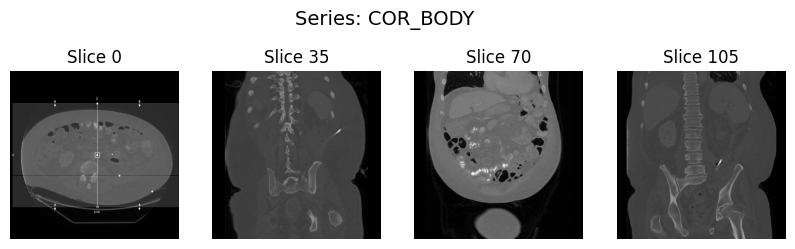

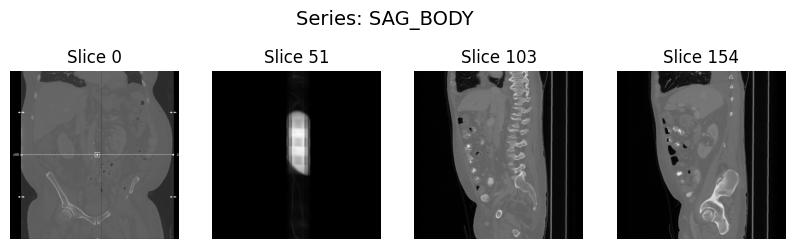

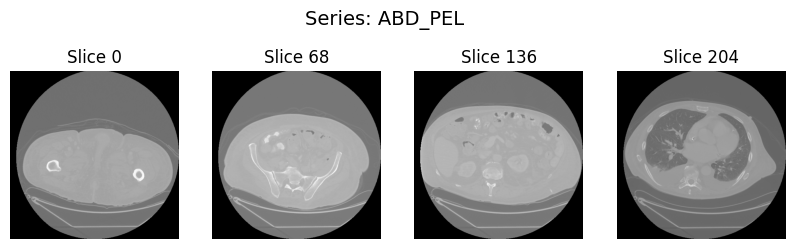

In [ ]:
import os
import pydicom
import matplotlib.pyplot as plt

case_folder = os.path.join(image_path, case_id)

# get only valid directories
series_list = [s for s in os.listdir(case_folder)
               if os.path.isdir(os.path.join(case_folder, s))]

# loop through each series
for series in series_list:
    series_path = os.path.join(case_folder, series)

    # get dicom files
    files = [f for f in os.listdir(series_path)
             if os.path.isfile(os.path.join(series_path, f))]

    # skip empty
    if len(files) == 0:
        continue

    # read dicoms
    dicoms = []
    for f in files:
        try:
            dcm = pydicom.dcmread(os.path.join(series_path, f))
            dicoms.append(dcm)
        except:
            continue

    if len(dicoms) < 4:
        continue

    # sort slices properly
    try:
        dicoms.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    except:
        pass  # fallback if tag missing

    # pick 4 evenly spaced slices
    indices = [0, len(dicoms)//3, 2*len(dicoms)//3, len(dicoms)-1]

    # plot
    plt.figure(figsize=(10, 3))
    plt.suptitle(f"Series: {series}", fontsize=14)

    for i, idx in enumerate(indices):
        plt.subplot(1, 4, i+1)
        plt.imshow(dicoms[idx].pixel_array, cmap='gray')
        plt.title(f"Slice {idx}")
        plt.axis('off')

    plt.show()

In [ ]:
import numpy as np

def normalize(img):
    img = np.clip(img, -1000, 400)
    return (img + 1000) / 1400


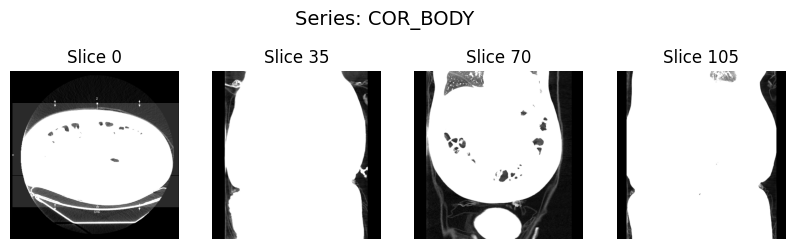

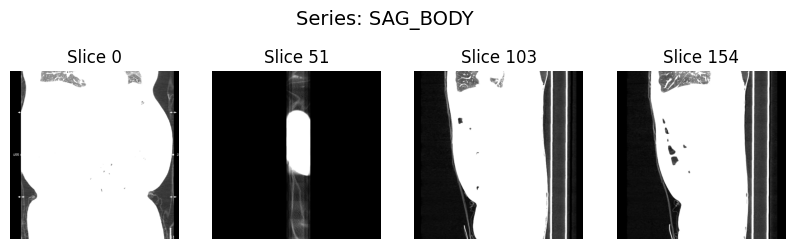

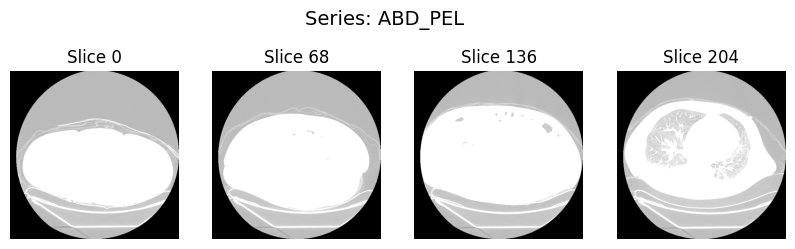

In [ ]:
import os
import pydicom
import matplotlib.pyplot as plt

case_folder = os.path.join(image_path, case_id)

# get only valid directories
series_list = [s for s in os.listdir(case_folder)
               if os.path.isdir(os.path.join(case_folder, s))]

# loop through each series
for series in series_list:
    series_path = os.path.join(case_folder, series)

    # get dicom files
    files = [f for f in os.listdir(series_path)
             if os.path.isfile(os.path.join(series_path, f))]

    # skip empty
    if len(files) == 0:
        continue

    # read dicoms
    dicoms = []
    for f in files:
        try:
            dcm = pydicom.dcmread(os.path.join(series_path, f))
            dicoms.append(dcm)
        except:
            continue

    if len(dicoms) < 4:
        continue

    # sort slices properly
    try:
        dicoms.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    except:
        pass  # fallback if tag missing

    # pick 4 evenly spaced slices
    indices = [0, len(dicoms)//3, 2*len(dicoms)//3, len(dicoms)-1]

    # plot
    plt.figure(figsize=(10, 3))
    plt.suptitle(f"Series: {series}", fontsize=14)

    for i, idx in enumerate(indices):
        plt.subplot(1, 4, i+1)
        plt.imshow(normalize(dicoms[idx].pixel_array), cmap='gray')
        plt.title(f"Slice {idx}")
        plt.axis('off')

    plt.show()

🆔 CASE ID: 10008

🩺 Clinical Indication:

eval for small bowel fistula, perinephric hematoma resolved, but now with air possibly communicating with small bowel

📄 Preliminary Report:

PRELIMINARY INPATIENT FINDINGS/IMPRESSION
 
In response to the clinical question,
 
Similar appearance of perinephric fluid collection, now with mild increase in layering fluid at the superior most aspect of the collection (3/82).
 
Though the matted bowel loops are not and endoluminally opacified by contrast to directly demonstrate fistulous communication with the fluid collection, there remains a high probability given proximity and soft tissue bridging between the small bowel and the collection, for example (125-129).
 
The remainder of the examination is unchanged from recent prior. 
 
There are no additional acute / emergent findings in the chest, abdomen and pelvis. Please see final report for further details.



✏️ Candidate Edits:

10008_01 → A left renal angiomyolipoma measuring approximately 3.5

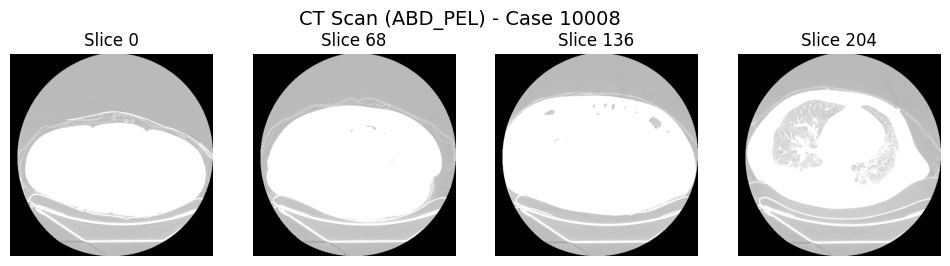

In [ ]:
import os
import json
import pydicom
import matplotlib.pyplot as plt
import numpy as np

# -------- PATHS (UPDATE IF NEEDED) --------
base_path = "/content/drive/My Drive/MediqaRadar02"

report_path = os.path.join(base_path, "dev_preliminary_report")
image_path = os.path.join(base_path, "image_dev")
json_path = os.path.join(base_path, "dev_edits.json")

# -------- LOAD JSON --------
with open(json_path, 'r') as f:
    data = json.load(f)

# -------- PICK ONE CASE --------
case = data[0]   # change index to explore more
case_id = str(case['case_id'])

print("="*80)
print(f"🆔 CASE ID: {case_id}")
print("="*80)

# -------- SHOW CLINICAL INDICATION --------
print("\n🩺 Clinical Indication:\n")
print(case['clinical_indication'])

# -------- SHOW REPORT --------
report_file = os.path.join(report_path, f"{case_id}.txt")

print("\n📄 Preliminary Report:\n")
with open(report_file, 'r') as f:
    report_text = f.read()
print(report_text)

# -------- SHOW EDITS --------
print("\n✏️ Candidate Edits:\n")
for edit in case['edits'][:5]:  # show first 5
    print(f"{edit['edit_id']} → {edit['suggested_edit_text']}")

# -------- LOAD CT IMAGES --------
case_folder = os.path.join(image_path, case_id)

# filter valid series
series_list = [s for s in os.listdir(case_folder)
               if os.path.isdir(os.path.join(case_folder, s))
               and "SCOUT" not in s.upper()]

print("\n🖼️ Available Series:", series_list)

# choose best series
if "ABD_PEL" in series_list:
    selected_series = "ABD_PEL"
else:
    selected_series = series_list[0]

print("📌 Selected Series:", selected_series)

series_path = os.path.join(case_folder, selected_series)

# load dicom files
dicoms = []
for f in os.listdir(series_path):
    try:
        dcm = pydicom.dcmread(os.path.join(series_path, f))
        dicoms.append(dcm)
    except:
        pass

# sort slices properly
try:
    dicoms.sort(key=lambda x: float(x.ImagePositionPatient[2]))
except:
    pass

# -------- NORMALIZATION FUNCTION --------
def normalize(img):
    img = np.clip(img, -1000, 400)
    return (img + 1000) / 1400

# -------- SHOW CT SLICES --------
indices = [0, len(dicoms)//3, 2*len(dicoms)//3, len(dicoms)-1]

plt.figure(figsize=(12, 3))
plt.suptitle(f"CT Scan ({selected_series}) - Case {case_id}", fontsize=14)

for i, idx in enumerate(indices):
    plt.subplot(1, 4, i+1)
    plt.imshow(normalize(dicoms[idx].pixel_array), cmap='gray')
    plt.title(f"Slice {idx}")
    plt.axis('off')

plt.show()

In [ ]:
series_list = [s for s in series_list if "SCOUT" not in s.upper()]

In [ ]:
# prefer ABD_PEL if exists
if "ABD_PEL" in series_list:
    selected_series = "ABD_PEL"
else:
    selected_series = series_list[0]

print("Selected series:", selected_series)

series_path = os.path.join(case_folder, selected_series)

Selected series: ABD_PEL


In [ ]:
dicom_files = []

for f in os.listdir(series_path):
    file_path = os.path.join(series_path, f)

    # ensure it's a file (not folder)
    if os.path.isfile(file_path):
        try:
            dcm = pydicom.dcmread(file_path)
            dicom_files.append(dcm)
        except:
            pass  # skip non-dicom or corrupted files

print("Loaded slices:", len(dicom_files))

Loaded slices: 205


In [ ]:
# sort properly
dicom_files.sort(key=lambda x: float(x.ImagePositionPatient[2]))

volume = np.stack([d.pixel_array for d in dicom_files])

print("Volume shape:", volume.shape)

Volume shape: (205, 512, 512)


In [ ]:
!git clone https://github.com/GeraldSun/RADAR.git

Cloning into 'RADAR'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 80 (delta 25), reused 44 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 13.60 MiB | 6.08 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [ ]:
!pip install pandas scikit-learn numpy

In [ ]:
import pandas as pd

example = pd.read_csv("RADAR/eval/example_submission.csv")
example.head()

,edit_id,agreement_pred,severity_pred,edit_type_pred
0,10008_01,partially agree,negligible,clarification
1,10008_02,partially agree,negligible,addition
2,10008_03,agree,negligible,correction
3,10008_04,disagree,negligible,addition
4,10008_05,partially agree,critical,correction


In [ ]:
import pandas as pd
import json

# load edits
with open(json_path, 'r') as f:
    data = json.load(f)

rows = []

for case in data:
    case_id = str(case['case_id'])

    for edit in case['edits']:
        edit_id = edit['edit_id']
        text = edit['suggested_edit_text'].lower()

        # 🔹 VERY SIMPLE RULES (baseline)

        # agreement
        if "no" in text or "not" in text:
            agreement = "disagree"
        else:
            agreement = "agree"

        # severity
        if "mass" in text or "tumor" in text:
            severity = "critical"
        elif "mild" in text:
            severity = "negligible"
        else:
            severity = "moderate"

        # edit type
        if "instead" in text or "should be" in text:
            edit_type = "correction"
        elif "also" in text or "add" in text:
            edit_type = "addition"
        else:
            edit_type = "clarification"

        rows.append([edit_id, agreement, severity, edit_type])

# create dataframe
submission = pd.DataFrame(rows, columns=[
    "edit_id", "agreement_pred", "severity_pred", "edit_type_pred"
])

# save
submission.to_csv("my_submission.csv", index=False)

print("Submission file created!")

Submission file created!


In [ ]:
!python RADAR/eval/eval.py \
  --submission my_submission.csv \
  --groundtruth RADAR/eval/groundtruth_dev.csv \
  --output results.json

{
  "agreement_accuracy": 0.5217391304347826,
  "severity_accuracy": 0.29347826086956524,
  "edit_type_accuracy": 0.21739130434782608,
  "composite_score": 0.03260869565217391
}

Results written to results.json


In [ ]:
import json

with open("results.json") as f:
    results = json.load(f)

print(results)

{'agreement_accuracy': 0.5217391304347826, 'severity_accuracy': 0.29347826086956524, 'edit_type_accuracy': 0.21739130434782608, 'composite_score': 0.03260869565217391}


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression